In [2]:
import pandas as pd  
from scan_spectrolyser import scan_helpers
from scan_spectrolyser import no3_calibrations
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter


In [3]:
path = '/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/KelpNet/Data/9-10-24 Seawater Experiments/'

di  = scan_helpers.import_scan_fp(path+'5um_0sw.fp')
half_sw  = scan_helpers.import_scan_fp(path+'5um_50sw.fp')
sw  = scan_helpers.import_scan_fp(path+'5um_100sw.fp')

# Plotting of Raw Spectra

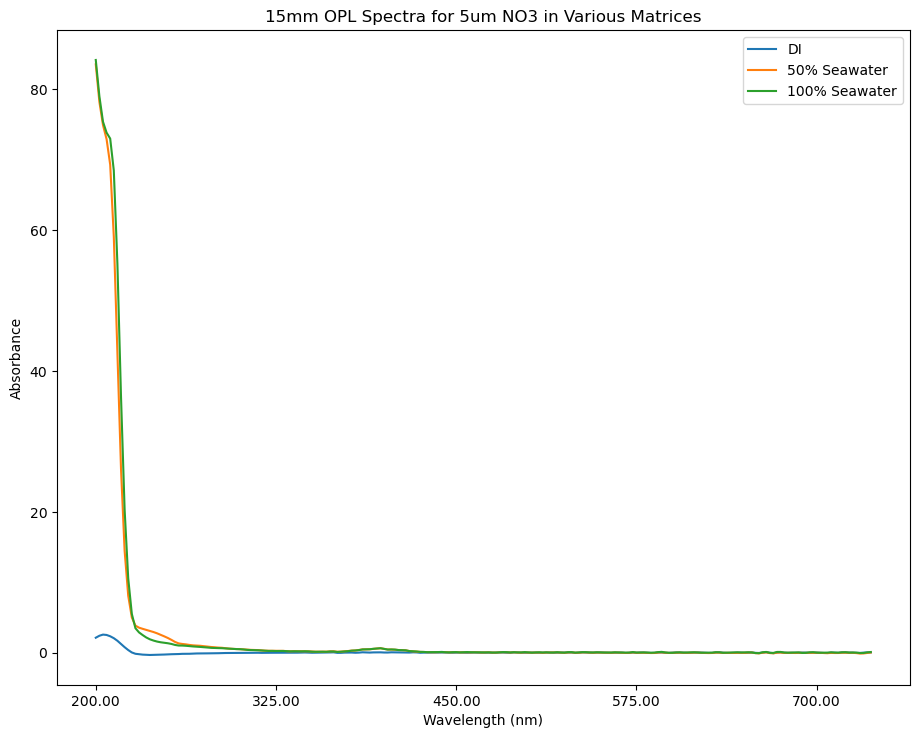

In [4]:
fig, ax = plt.subplots(figsize=(11,8.5))

scan_helpers.plot_scan_fp(di, 0, ax=ax, label='DI')
scan_helpers.plot_scan_fp(half_sw, 0, ax=ax, label='50% Seawater')
scan_helpers.plot_scan_fp(sw, 0, ax=ax, label='100% Seawater', title = '15mm OPL Spectra for 5um NO3 in Various Matrices')

- unsurprisingly, raw spectra for 5um NO3 in DI and seawater are very different, likely from bromide
- it looks the spectrometer saturates going from 50% seawater to 100% seawater. Probably means we need to use 5mm OPL, not 15mm OPL

# Plotting 2nd derivative spectra

In [5]:
def calc_2d(df, window_size, poly_order):
    df_2d = df.drop('Date/Time', axis=1).transform(lambda x: savgol_filter(x, window_size, poly_order, deriv=2),axis=1)
    df_2d['Date/Time'] = df['Date/Time']
    return df_2d

di_2d = calc_2d(di, 3, 2)
sw_2d = calc_2d(sw, 3, 2)
half_sw_2d = calc_2d(half_sw, 3, 2)

In [6]:
di_2d

,200.00,202.50,205.00,207.50,210.00,212.50,215.00,217.50,220.00,222.50,...,730.00,732.50,735.00,737.50,740.00,742.50,745.00,747.50,750.00,Date/Time
0,-0.1165,-0.1165,-0.2143,-0.1342,-0.0867,-0.0955,-0.0875,0.0022,0.0437,0.0693,...,0.039,0.0124,-0.0415,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-10 15:41:07
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-10 15:43:32


KeyError: "['second_derivative', 'second_derivative_no3'] not found in axis"

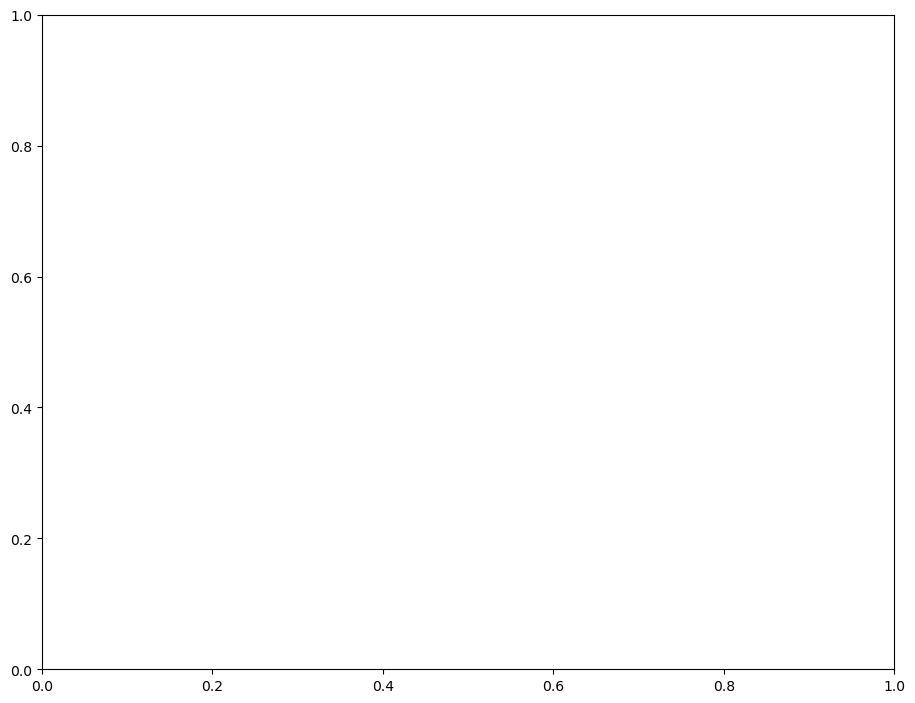

In [7]:
fig2, ax2 = plt.subplots(figsize=(11,8.5))



ax2.plot(di_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).columns, di_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).loc[0], label='DI')
ax2.plot(sw_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).columns, sw_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).loc[0], label='100% Seawater')
ax2.plot(half_sw_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).columns, half_sw_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).loc[0], label='50% Seawater')

ax2.legend()
ax2.set_title('15mm OPL Second Derivative Spectra for 5um NO3 in Various Matrices')
ax2.set_xlim('220.00', '250.00')
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Second Derivative of Absorbance')

- Was previously looking at 227.50 nm as the best wavelength for second-derivative spectroscopy for nitrate. 
- Pretty clearly there is a seawater-related response at 227.50 nm

Text(0.5, 1.0, 'Second Derivative Spectrum of 5um Nitrate in DI Water')

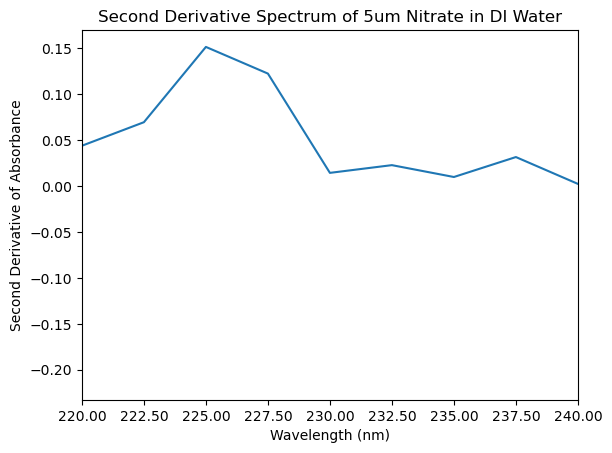

In [ ]:
fig3, ax3 = plt.subplots()

ax3.plot(di_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).columns, di_2d.drop(['second_derivative', 'second_derivative_no3', 'Date/Time'], axis=1).loc[0], label='DI')
ax3.set_xlim('220.00', '240.00')
ax3.set_xlabel('Wavelength (nm)')
ax3.set_ylabel('Second Derivative of Absorbance')
ax3.set_title('Second Derivative Spectrum of 5um Nitrate in DI Water')

# What is absorbance at 220nm?

In [ ]:
di_2d['220.00']

0    0.0437
1       NaN
Name: 220.00, dtype: float64

In [ ]:
half_sw['220.00']

0    14.5071
Name: 220.00, dtype: float64

In [ ]:
sw['220.00']

0    20.3579
1        NaN
2        NaN
Name: 220.00, dtype: float64

# Plotting Results of Spiking Tests

- hmm. half_sw 220 nm absorbance is not half of sw 220nm absorbance. Could be from DOM from the plastic carboy tho.

In [8]:
path = '/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/KelpNet/Data/10-2-24 SCAN Seawater Recovery/'

sw_0um  = scan_helpers.import_scan_fp(path+'gw_sw_0um.fp')
sw_5um = scan_helpers.import_scan_fp(path+'gw_sw_5um.fp')
sw_10um  = scan_helpers.import_scan_fp(path+'gw_sw_10um.fp')

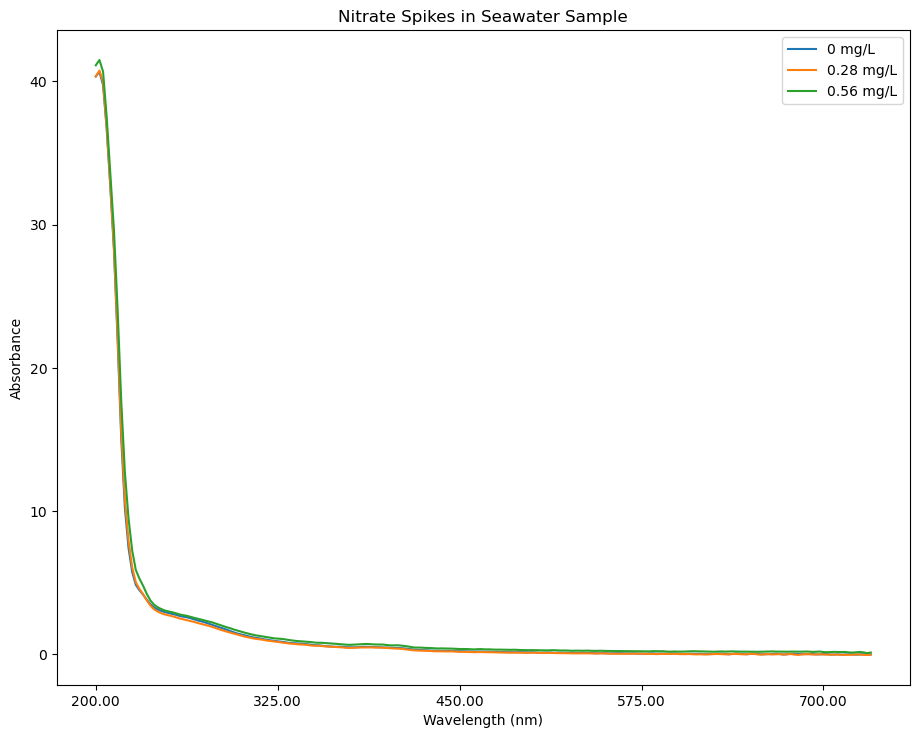

In [9]:
fig3, ax3= plt.subplots(figsize=(11,8.5))

scan_helpers.plot_scan_fp(sw_0um, 0, ax=ax3, label='0 mg/L')
scan_helpers.plot_scan_fp(sw_5um , 0, ax=ax3, label='0.28 mg/L')
scan_helpers.plot_scan_fp(sw_10um , 0, ax=ax3, label='0.56 mg/L', title = 'Nitrate Spikes in Seawater Sample')

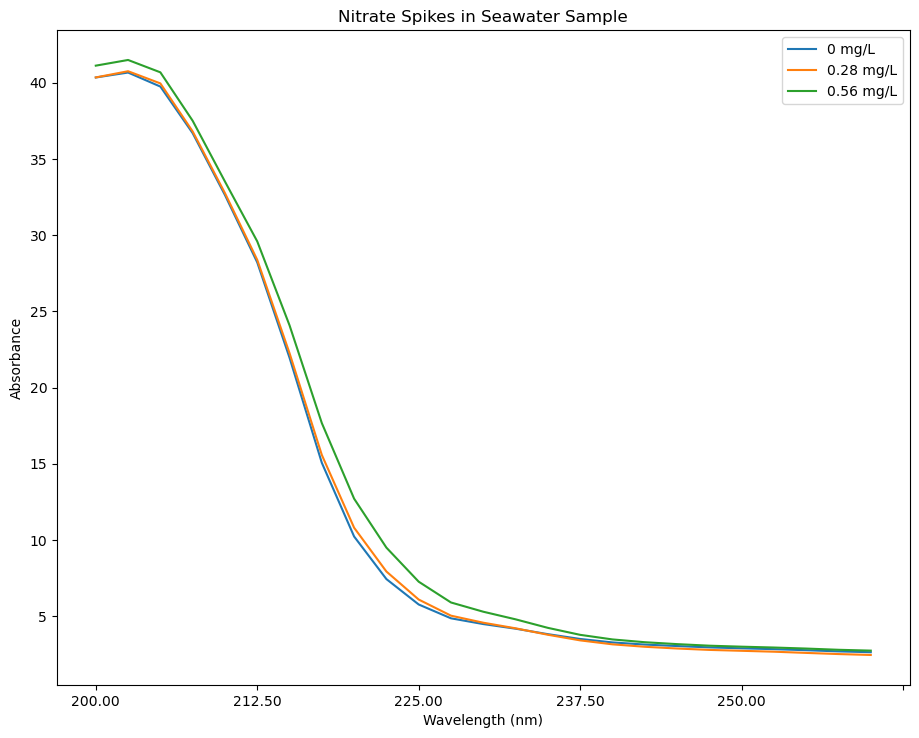

In [30]:
fig3, ax3= plt.subplots(figsize=(11,8.5))

columns = [f"{wavelength/10:.2f}" for wavelength in range(2000, 2625, 25)]
columns.insert(0,'Date/Time')

scan_helpers.plot_scan_fp(sw_0um[columns], 0, ax=ax3, label='0 mg/L')
scan_helpers.plot_scan_fp(sw_5um[columns] , 0, ax=ax3, label='0.28 mg/L')
scan_helpers.plot_scan_fp(sw_10um[columns] , 0, ax=ax3, label='0.56 mg/L', title = 'Nitrate Spikes in Seawater Sample')


In [27]:
columns

In [19]:
columns = [f"{wavelength/10:.2f}" for wavelength in range(2000, 2625, 25)]


In [29]:
columns